In [1]:
from google.colab import files
uploaded = files.upload()

Saving Student Depression Dataset.csv to Student Depression Dataset.csv


In [2]:
import os
os.listdir()

['.config', 'Student Depression Dataset.csv', 'sample_data']

In [3]:
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [5]:
df = pd.read_csv("Student Depression Dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [6]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [8]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [23]:
features = [
    "Age",
    "Academic Pressure",
    "CGPA",
    "Sleep Duration",
    "Work/Study Hours",
    "Financial Stress"
]

X = df[features]
y = df["Depression"]

In [24]:
### Identify Column Types
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['Age', 'Academic Pressure', 'CGPA', 'Work/Study Hours', 'Financial Stress']
Categorical: ['Sleep Duration']


In [25]:
###########------------------ Preprocessing

#Numerical
numerical_transformer  = SimpleImputer(strategy='mean')

#Categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [26]:
#### Train_test slip

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

In [27]:
###########--------------- Build Model Pipeline

model =  RandomForestClassifier(n_estimators=100,random_state=0)

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])



In [28]:
## Train Model

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Age', 'Academic Pressure',
                                                   'CGPA', 'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sleep Duration'])])),
                ('model', RandomForestClassifier(random_state=0))])

In [29]:
### Make Predictions

preds = pipeline.predict(X_valid)

In [30]:
### Evaluate Model

print("Accuracy:", accuracy_score(y_valid, preds))
print(classification_report(y_valid, preds))

Accuracy: 0.764737502239742
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      2326
           1       0.79      0.81      0.80      3255

    accuracy                           0.76      5581
   macro avg       0.76      0.76      0.76      5581
weighted avg       0.76      0.76      0.76      5581



In [ ]:
''' Conclusion : The model achieved ~76% accuracy, which is reasonable for a mixed behavioral dataset.
However, performance can be improved using feature engineering, hyperparameter tuning, and trying models like XGBoost.
'''

In [31]:
###########---------Cross Validation

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring= 'accuracy')
print("Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Accuracy: 0.7598655576813036


In [ ]:
''' model is stable
✔ not overfitting much
✔ generalization is consistent
'''

In [ ]:
'''Conclusion :
The model achieved ~76% accuracy with Random Forest, and cross-validation score is also around 76%,
which indicates the model is stable and generalizes well without overfitting.
'''

In [32]:
#########------------XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=0
)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

xgb_preds = xgb_pipeline.predict(X_valid)

print("XGBoost Accuracy:", accuracy_score(y_valid, xgb_preds))



XGBoost Accuracy: 0.7939437376814191


In [33]:
###----Check feature importance

import numpy as np

model = pipeline.named_steps['model']

importances = model.feature_importances_

print(importances)

[1.75269289e-01 2.19774115e-01 2.90206315e-01 1.41624140e-01
 1.31435263e-01 1.03569640e-02 1.04312388e-02 1.06058374e-02
 1.01160936e-02 1.80742765e-04]


In [ ]:
'''Higher number = more influence on prediction'''

In [34]:
print("Random Forest:", accuracy_score(y_valid, preds))
print("XGBoost:", accuracy_score(y_valid, xgb_preds))

Random Forest: 0.764737502239742
XGBoost: 0.7939437376814191


In [ ]:
'''I compared multiple models (Random Forest and XGBoost) and improved performance using advanced tuning techniques.
I used train/test split to compare multiple models and selected XGBoost as the best performer.
I then used cross-validation to verify that the model is stable and not dependent on a single data split.'''

In [ ]:
''' FINAL BEST MODEL = XGBoost pipeline '''

In [35]:
## Retrain final model on full data

final_model = xgb_pipeline

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['Age', 'Academic Pressure',
                                                   'CGPA', 'Work/Study Hours',
                                                   'Financial Stress']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sleep Duration'])])),
                ('model',
                 XGBClassifier(base_score=None, boos...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [36]:
print(X.columns)

Index(['Age', 'Academic Pressure', 'CGPA', 'Sleep Duration',
       'Work/Study Hours', 'Financial Stress'],
      dtype='object')


In [38]:
import os

if os.path.exists("student_depression_model.pkl"):
    print("Old model will be replaced")

In [39]:
## Save the final model

import joblib

joblib.dump(final_model, "student_depression_model.pkl")

['student_depression_model.pkl']

In [40]:
## Create prediction function

def predict_depression(input_data):
    prediction = final_model.predict(input_data)
    return prediction

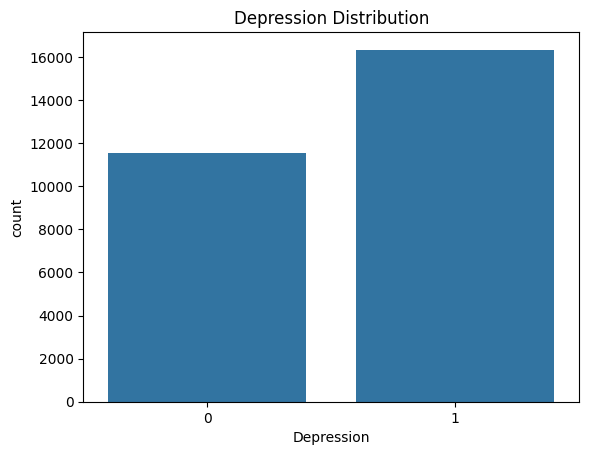

In [41]:
#########################----------------Visualizations------------####################

### Target distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y, data=df)
plt.title("Depression Distribution")
plt.show()


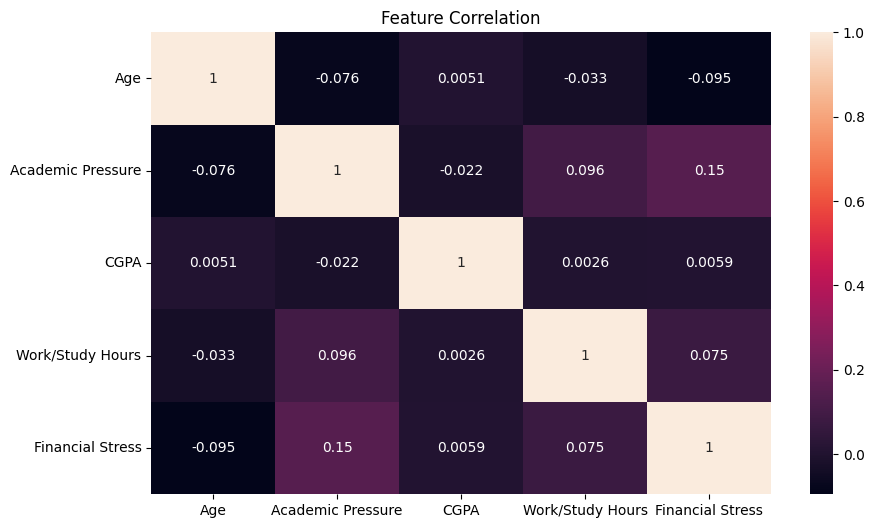

In [42]:
## Correlation heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

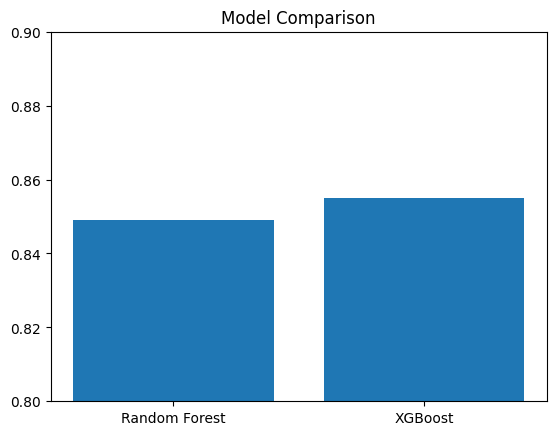

In [43]:
models = ['Random Forest', 'XGBoost']
scores = [0.849, 0.855]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylim(0.8, 0.9)
plt.show()

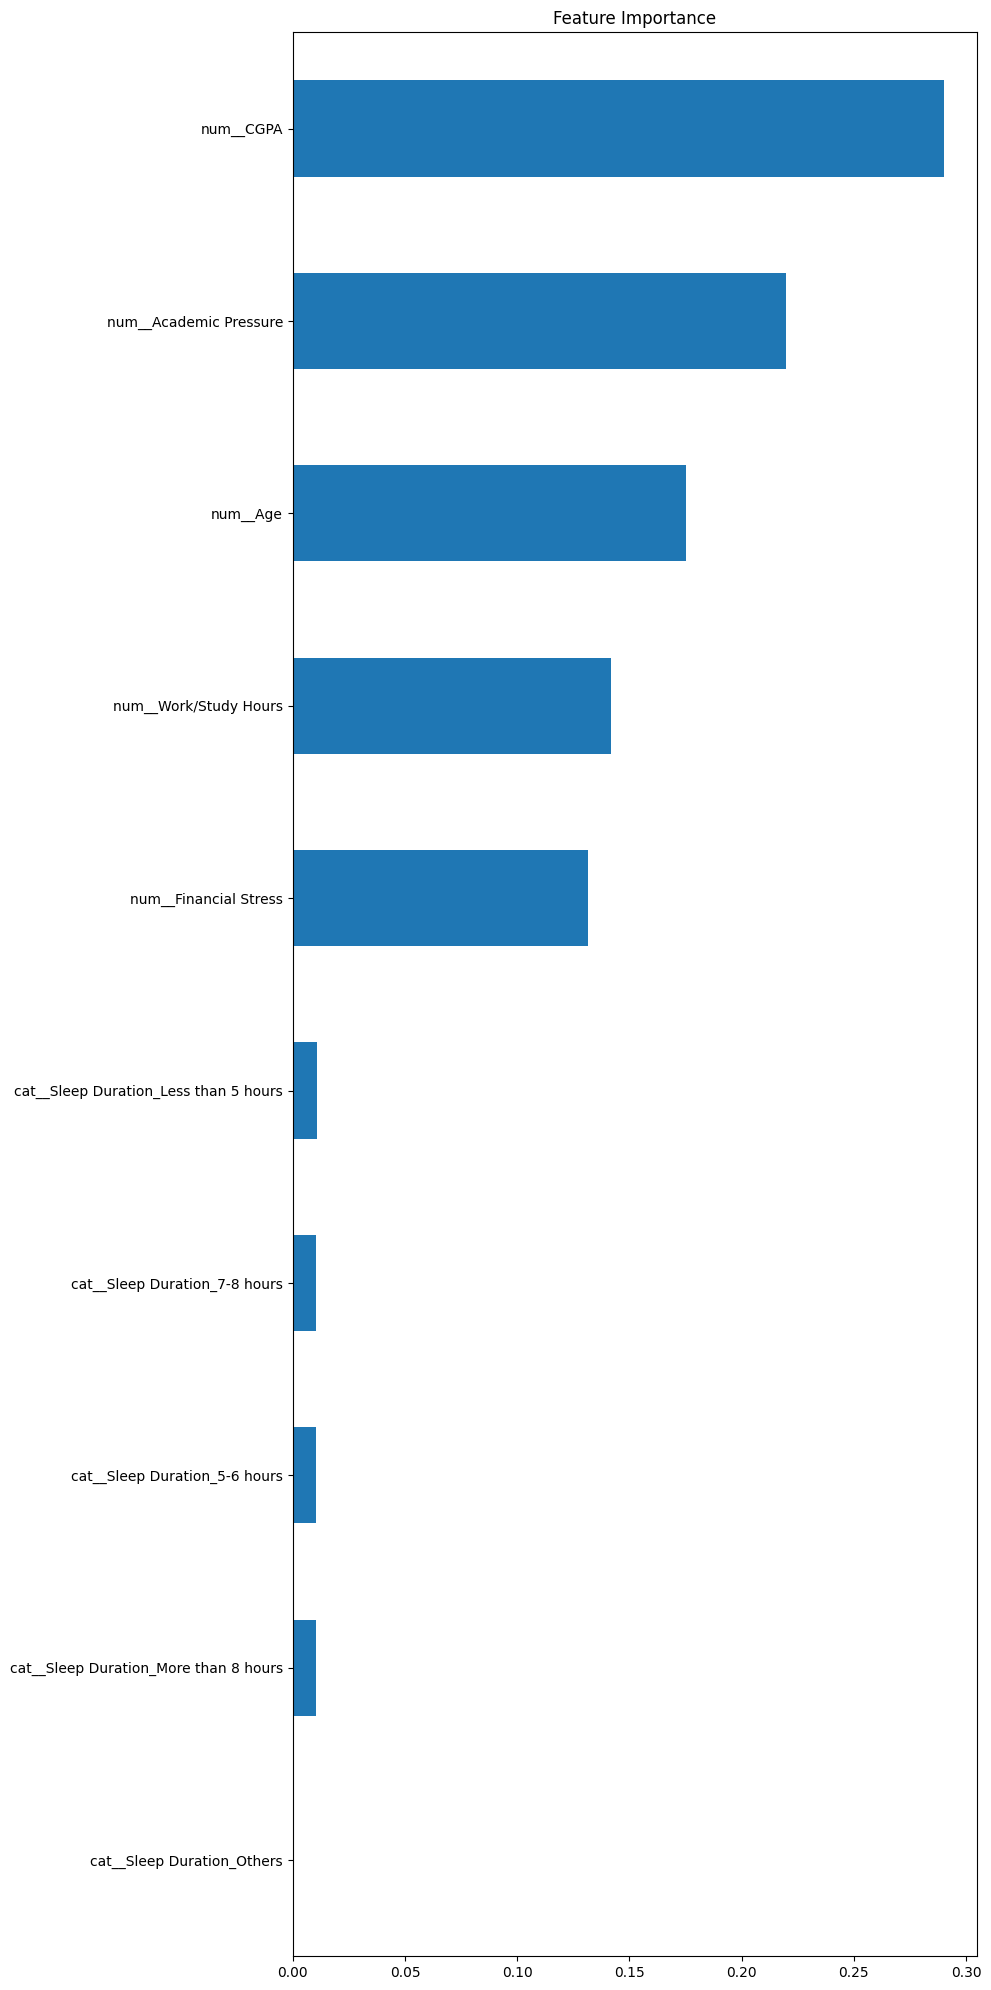

In [44]:
###### Feature importance

# Get the transformed X_train data which was used to train the model
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)

# Convert to a dense array if sparse, for variance calculation
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed_dense = X_train_transformed.toarray()
else:
    X_train_transformed_dense = X_train_transformed

# Get all feature names generated by the preprocessor
all_feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Identify non-constant features based on their variance in the transformed training data
# Features with zero variance are constant and are often implicitly ignored by models
# or do not contribute to feature importances.
feature_variances = np.var(X_train_transformed_dense, axis=0)
non_constant_feature_indices = np.where(feature_variances > 0)[0]

# Filter the feature names to include only non-constant ones
feature_names = all_feature_names[non_constant_feature_indices]

# Create the Series with the aligned importances and feature names
importance_df = pd.Series(importances, index=feature_names)
importance_df.sort_values(ascending=True).plot(kind='barh', figsize=(10, 20))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [45]:
from google.colab import files
files.download("student_depression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>